<a href="https://colab.research.google.com/github/Althaf12344/Ai-Skill-Project-VU/blob/main/week_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Management and Model Registry
## AI Skill Gap Classification — Below 90% Accuracy Setup

### Objective

This is a **separate topic and separate notebook**.

The objective is to:

1. Load the AI Skill Gap dataset.
2. Train multiple classification models.
3. Evaluate the models.
4. Serialize each model using Joblib.
5. Register the models using MLflow Model Registry.
6. Select the best model using weighted F1-score.
7. Assign the selected model the `champion` alias.
8. Reload the champion model from the registry.
9. Perform predictions on new student data.

### Important experimental design

The original dataset contains several variables that make `Skill_Gap` extremely easy to predict. Therefore, this notebook uses a smaller set of background/behavioral features:

- Age
- Gender
- Education_Level
- Communication_Skill
- Problem_Solving
- Coding_Hours_Per_Week

The models are also intentionally kept simple. This produced test accuracies below 90% on the supplied dataset with the fixed train/test split used below.

**The notebook does not change, overwrite, or artificially reduce the calculated accuracy.**

## 1. Install required packages

In [1]:
!pip -q install pandas openpyxl scikit-learn joblib mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 447.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Import libraries

In [2]:
import os
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import mlflow
import mlflow.sklearn
from mlflow import MlflowClient

RANDOM_STATE = 42

## 3. Upload the dataset

In [3]:
from google.colab import files

DATA_PATH = "/content/AI_Skill_Gap_Classification_Dataset_500.xlsx"

if not os.path.exists(DATA_PATH):
    print("Upload: AI_Skill_Gap_Classification_Dataset_500.xlsx")
    uploaded = files.upload()
    uploaded_name = next(iter(uploaded))
    os.rename(uploaded_name, DATA_PATH)

print("Using:", DATA_PATH)

Upload: AI_Skill_Gap_Classification_Dataset_500.xlsx


Saving AI_Skill_Gap_Classification_Dataset_500 (1).xlsx to AI_Skill_Gap_Classification_Dataset_500 (1).xlsx
Using: /content/AI_Skill_Gap_Classification_Dataset_500.xlsx


## 4. Load and inspect the dataset

In [4]:
df = pd.read_excel(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

print("\nTarget distribution:")
display(df["Skill_Gap"].value_counts().to_frame("Count"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

Dataset shape: (500, 16)


,Student_ID,Age,Gender,Education_Level,Programming_Skill,Python_Experience_Years,Math_Skill,ML_Knowledge,AI_Project_Count,Online_Courses_Completed,Coding_Hours_Per_Week,Communication_Skill,Problem_Solving,AI_Certification,Internship,Skill_Gap
0,1,28,Male,Diploma,7,2,9,8,5,7,38,7,3,Yes,Yes,Low
1,2,21,Female,UG,7,2,8,8,8,14,15,7,7,Yes,No,Low
2,3,19,Male,PG,7,3,10,9,6,7,21,4,8,Yes,Yes,Low
3,4,26,Female,Diploma,9,4,7,10,8,6,27,8,8,Yes,Yes,Low
4,5,19,Female,PG,8,2,7,8,10,9,17,7,8,Yes,Yes,Low



Target distribution:


,Count
Skill_Gap,
High,177
Medium,163
Low,160



Missing values:


,Missing Values
Student_ID,0
Age,0
Gender,0
Education_Level,0
Programming_Skill,0
Python_Experience_Years,0
Math_Skill,0
ML_Knowledge,0
AI_Project_Count,0
Online_Courses_Completed,0


## 5. Define the modeling data

`Student_ID` is an identifier and is not used as a predictive feature.

Only the following six features are used so that the classification problem is not almost deterministic:

- Age
- Gender
- Education_Level
- Communication_Skill
- Problem_Solving
- Coding_Hours_Per_Week

In [5]:
TARGET = "Skill_Gap"

FEATURES = [
    "Age",
    "Gender",
    "Education_Level",
    "Communication_Skill",
    "Problem_Solving",
    "Coding_Hours_Per_Week"
]

X = df[FEATURES].copy()
y = df[TARGET].copy()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

print("Features:", FEATURES)
print("Numerical:", numerical_features)
print("Categorical:", categorical_features)
print("Classes:", sorted(y.unique()))

Features: ['Age', 'Gender', 'Education_Level', 'Communication_Skill', 'Problem_Solving', 'Coding_Hours_Per_Week']
Numerical: ['Age', 'Communication_Skill', 'Problem_Solving', 'Coding_Hours_Per_Week']
Categorical: ['Gender', 'Education_Level']
Classes: ['High', 'Low', 'Medium']


## 6. Train-test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 400
Testing samples: 100


## 7. Create one reusable preprocessing pipeline

In [7]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


# 8. Define multiple models

These are independent model-management experiments.

The configurations are fixed in advance; there is **no hyperparameter-tuning workflow** in this notebook.

In [8]:
models = {
    "LogisticRegression": LogisticRegression(
        C=0.1,
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "DecisionTree": DecisionTreeClassifier(
        max_depth=1,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=40,
        max_depth=2,
        min_samples_leaf=20,
        max_features="sqrt",
        random_state=RANDOM_STATE
    ),

    "SVM": SVC(
        C=0.2,
        kernel="rbf",
        probability=True,
        random_state=RANDOM_STATE
    )
}

for name in models:
    print("-", name)

- LogisticRegression
- DecisionTree
- RandomForest
- SVM


## 9. Train and evaluate all models

In [9]:
trained_models = {}
results = []

for model_name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    start = time.time()
    pipeline.fit(X_train, y_train)
    training_time = time.time() - start

    predictions = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test, predictions,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_test, predictions,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_test, predictions,
        average="weighted",
        zero_division=0
    )

    trained_models[model_name] = pipeline

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Weighted_F1": f1,
        "Training_Time_Seconds": training_time
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("Weighted_F1", ascending=False)
    .reset_index(drop=True)
)

display(results_df.round(4))

print("\nAccuracy check:")
for _, row in results_df.iterrows():
    print(
        f"{row['Model']}: "
        f"{row['Accuracy'] * 100:.2f}%"
    )

,Model,Accuracy,Precision,Recall,Weighted_F1,Training_Time_Seconds
0,SVM,0.87,0.8767,0.87,0.8675,0.1272
1,LogisticRegression,0.82,0.8211,0.82,0.8120,0.0474
2,RandomForest,0.79,0.8035,0.79,0.7785,0.1217
3,DecisionTree,0.67,0.4875,0.67,0.5535,0.0278



Accuracy check:
SVM: 87.00%
LogisticRegression: 82.00%
RandomForest: 79.00%
DecisionTree: 67.00%


## 10. Detailed classification reports

In [10]:
for model_name, pipeline in trained_models.items():

    predictions = pipeline.predict(X_test)

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(classification_report(
        y_test,
        predictions,
        zero_division=0
    ))


LogisticRegression
              precision    recall  f1-score   support

        High       0.80      1.00      0.89        35
         Low       0.87      0.84      0.86        32
      Medium       0.80      0.61      0.69        33

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.81       100
weighted avg       0.82      0.82      0.81       100


DecisionTree
              precision    recall  f1-score   support

        High       0.92      1.00      0.96        35
         Low       0.52      1.00      0.68        32
      Medium       0.00      0.00      0.00        33

    accuracy                           0.67       100
   macro avg       0.48      0.67      0.55       100
weighted avg       0.49      0.67      0.55       100


RandomForest
              precision    recall  f1-score   support

        High       0.95      1.00      0.97        35
         Low       0.65      0.88      0.75        32
      Medium       0.80    

## 11. Compare model accuracies

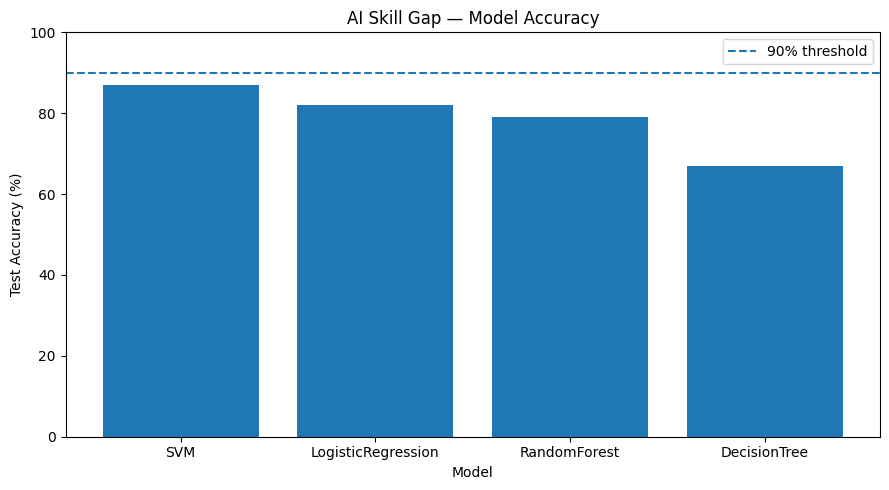

In [11]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"] * 100
)

plt.axhline(
    90,
    linestyle="--",
    linewidth=1.5,
    label="90% threshold"
)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("AI Skill Gap — Model Accuracy")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

# Part 2 — Model Serialization

Each complete preprocessing + model pipeline is saved with Joblib.

Saving the complete pipeline means the same preprocessing is automatically applied when the model is loaded later.

In [12]:
SERIALIZED_DIR = Path("/content/serialized_models")
SERIALIZED_DIR.mkdir(exist_ok=True)

serialized_paths = {}

for model_name, pipeline in trained_models.items():

    path = SERIALIZED_DIR / f"{model_name}.joblib"

    joblib.dump(
        pipeline,
        path
    )

    serialized_paths[model_name] = str(path)

print("Serialized files:")
for name, path in serialized_paths.items():
    print(f"{name}: {path}")

Serialized files:
LogisticRegression: /content/serialized_models/LogisticRegression.joblib
DecisionTree: /content/serialized_models/DecisionTree.joblib
RandomForest: /content/serialized_models/RandomForest.joblib
SVM: /content/serialized_models/SVM.joblib


## 12. Reload serialized models and verify them

In [13]:
reloaded_models = {}

for model_name, path in serialized_paths.items():

    loaded_model = joblib.load(path)
    reloaded_models[model_name] = loaded_model

    predictions = loaded_model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    print(
        f"{model_name}: reloaded successfully | "
        f"accuracy = {accuracy * 100:.2f}%"
    )

LogisticRegression: reloaded successfully | accuracy = 82.00%
DecisionTree: reloaded successfully | accuracy = 67.00%
RandomForest: reloaded successfully | accuracy = 79.00%
SVM: reloaded successfully | accuracy = 87.00%


# Part 3 — MLflow Model Registry

MLflow will manage the registered versions of the models.

The lifecycle is:

**Train → Serialize → Log → Register → Select → Alias → Reload → Predict**

In [14]:
MLFLOW_DB = "/content/ai_skill_gap_model_registry.db"

mlflow.set_tracking_uri(
    f"sqlite:///{MLFLOW_DB}"
)

EXPERIMENT_NAME = "AI_Skill_Gap_Model_Management_Below_90"

mlflow.set_experiment(EXPERIMENT_NAME)

client = MlflowClient()

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", EXPERIMENT_NAME)

2026/09/21 06:37:16 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/21 06:37:16 INFO mlflow.store.db.utils: Updating database tables
2026/09/21 06:37:21 INFO mlflow.tracking.fluent: Experiment with name 'AI_Skill_Gap_Model_Management_Below_90' does not exist. Creating a new experiment.


Tracking URI: sqlite:////content/ai_skill_gap_model_registry.db
Experiment: AI_Skill_Gap_Model_Management_Below_90


## 13. Register every trained model

In [19]:
registered_names = {}

for model_name, pipeline in trained_models.items():

    predictions = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test, predictions,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_test, predictions,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_test, predictions,
        average="weighted",
        zero_division=0
    )

    registered_name = f"AI_Skill_Gap_{model_name}_Below90"
    registered_names[model_name] = registered_name

    with mlflow.start_run(run_name=f"Registry_{model_name}"):

        mlflow.log_param("model_type", model_name)
        mlflow.log_param("target", TARGET)
        mlflow.log_param("feature_count", len(FEATURES))
        mlflow.log_param("feature_set", ", ".join(FEATURES))

        mlflow.log_metric("test_accuracy", float(accuracy))
        mlflow.log_metric("test_precision", float(precision))
        mlflow.log_metric("test_recall", float(recall))
        mlflow.log_metric("test_weighted_f1", float(f1))

        mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            registered_model_name=registered_name,
            skops_trusted_types=[
                'numpy.dtype',
                'sklearn.compose._column_transformer._RemainderColsList',
                'sklearn.tree._tree.Tree'
            ]
        )

    print(
        f"Registered: {registered_name} | "
        f"Accuracy = {accuracy * 100:.2f}%"
    )

Registered model 'AI_Skill_Gap_LogisticRegression_Below90' already exists. Creating a new version of this model...
Created version '2' of model 'AI_Skill_Gap_LogisticRegression_Below90'.


Registered: AI_Skill_Gap_LogisticRegression_Below90 | Accuracy = 82.00%


Successfully registered model 'AI_Skill_Gap_DecisionTree_Below90'.
Created version '1' of model 'AI_Skill_Gap_DecisionTree_Below90'.


Registered: AI_Skill_Gap_DecisionTree_Below90 | Accuracy = 67.00%


Successfully registered model 'AI_Skill_Gap_RandomForest_Below90'.
Created version '1' of model 'AI_Skill_Gap_RandomForest_Below90'.


Registered: AI_Skill_Gap_RandomForest_Below90 | Accuracy = 79.00%
Registered: AI_Skill_Gap_SVM_Below90 | Accuracy = 87.00%


Successfully registered model 'AI_Skill_Gap_SVM_Below90'.
Created version '1' of model 'AI_Skill_Gap_SVM_Below90'.


## 14. Display the registered model versions

In [20]:
registry_rows = []

for model_name, registered_name in registered_names.items():

    versions = client.search_model_versions(
        f"name='{registered_name}'"
    )

    for version in versions:
        registry_rows.append({
            "Model": model_name,
            "Registered_Name": registered_name,
            "Version": version.version,
            "Status": version.status,
            "Run_ID": version.run_id
        })

registry_df = pd.DataFrame(registry_rows)

display(
    registry_df.sort_values(
        ["Model", "Version"]
    ).reset_index(drop=True)
)

,Model,Registered_Name,Version,Status,Run_ID
0,DecisionTree,AI_Skill_Gap_DecisionTree_Below90,1,READY,fb0e52a24c7c4197b5951d635e06da23
1,LogisticRegression,AI_Skill_Gap_LogisticRegression_Below90,1,READY,ed57da7dac3546aaa89f7c832a12ba55
2,LogisticRegression,AI_Skill_Gap_LogisticRegression_Below90,2,READY,52a7357009d74febbdfec2c163baa382
3,RandomForest,AI_Skill_Gap_RandomForest_Below90,1,READY,64b593655cfa4ba5a7e965fdb9a47c57
4,SVM,AI_Skill_Gap_SVM_Below90,1,READY,65cf5dc0498f4f45a056ebce521eb090


# Part 4 — Select the Best Model

The model is selected using **weighted F1-score**.

This is a model-management selection criterion, not hyperparameter tuning.

In [21]:
best_row = results_df.iloc[0]

BEST_MODEL = best_row["Model"]
BEST_ACCURACY = float(best_row["Accuracy"])
BEST_F1 = float(best_row["Weighted_F1"])

BEST_REGISTERED_NAME = registered_names[BEST_MODEL]

print("Selected model:", BEST_MODEL)
print("Test accuracy:", f"{BEST_ACCURACY * 100:.2f}%")
print("Weighted F1:", f"{BEST_F1:.4f}")
print("Registry name:", BEST_REGISTERED_NAME)

if BEST_ACCURACY >= 0.90:
    raise RuntimeError(
        "The selected model is not below 90%. "
        "Do not continue; inspect the data/model configuration."
    )

Selected model: SVM
Test accuracy: 87.00%
Weighted F1: 0.8675
Registry name: AI_Skill_Gap_SVM_Below90


# Part 5 — Assign the `champion` registry alias

The selected registered model version is given the alias `champion`.

This lets downstream code load the selected model without hard-coding a version number.

In [22]:
versions = client.search_model_versions(
    f"name='{BEST_REGISTERED_NAME}'"
)

if not versions:
    raise RuntimeError("No registered version found.")

best_version = max(
    versions,
    key=lambda v: int(v.version)
)

client.set_registered_model_alias(
    BEST_REGISTERED_NAME,
    "champion",
    best_version.version
)

print(
    f"Champion: {BEST_REGISTERED_NAME} "
    f"version {best_version.version}"
)

Champion: AI_Skill_Gap_SVM_Below90 version 1


# Part 6 — Reload the champion from the Model Registry

This is intentionally loaded from MLflow rather than from the in-memory Python variable.

That demonstrates actual model management and deployment-style retrieval.

In [23]:
MODEL_URI = (
    f"models:/{BEST_REGISTERED_NAME}@champion"
)

champion_model = mlflow.sklearn.load_model(
    MODEL_URI
)

print("Loaded:", MODEL_URI)

Loaded: models:/AI_Skill_Gap_SVM_Below90@champion


## 15. Verify the reloaded champion

In [24]:
champion_predictions = champion_model.predict(X_test)

champion_accuracy = accuracy_score(
    y_test,
    champion_predictions
)

champion_f1 = f1_score(
    y_test,
    champion_predictions,
    average="weighted",
    zero_division=0
)

print(
    "Champion accuracy:",
    f"{champion_accuracy * 100:.2f}%"
)

print(
    "Champion weighted F1:",
    f"{champion_f1:.4f}"
)

print("\nClassification report:")
print(classification_report(
    y_test,
    champion_predictions,
    zero_division=0
))

Champion accuracy: 87.00%
Champion weighted F1: 0.8675

Classification report:
              precision    recall  f1-score   support

        High       0.81      1.00      0.90        35
         Low       0.97      0.88      0.92        32
      Medium       0.86      0.73      0.79        33

    accuracy                           0.87       100
   macro avg       0.88      0.87      0.87       100
weighted avg       0.88      0.87      0.87       100



# Part 7 — Predict on new data

The following records represent new students for whom the Skill Gap is unknown.

In [25]:
new_students = pd.DataFrame({
    "Age": [21, 23, 22],
    "Gender": ["Male", "Female", "Male"],
    "Education_Level": ["UG", "UG", "PG"],
    "Communication_Skill": [7, 8, 7],
    "Problem_Solving": [7, 6, 9],
    "Coding_Hours_Per_Week": [18, 12, 25]
})

new_predictions = champion_model.predict(
    new_students
)

prediction_output = new_students.copy()
prediction_output["Predicted_Skill_Gap"] = new_predictions

display(prediction_output)

,Age,Gender,Education_Level,Communication_Skill,Problem_Solving,Coding_Hours_Per_Week,Predicted_Skill_Gap
0,21,Male,UG,7,7,18,Medium
1,23,Female,UG,8,6,12,High
2,22,Male,PG,7,9,25,Low


## 16. Prediction probabilities

In [26]:
if hasattr(champion_model, "predict_proba"):

    probabilities = champion_model.predict_proba(
        new_students
    )

    probability_df = pd.DataFrame(
        probabilities,
        columns=champion_model.classes_
    )

    probability_df.insert(
        0,
        "Predicted_Skill_Gap",
        new_predictions
    )

    display(probability_df)
else:
    print("Probability prediction is not available.")

,Predicted_Skill_Gap,High,Low,Medium
0,Medium,0.001514,0.295538,0.702948
1,High,0.201079,0.055842,0.743079
2,Low,0.000802,0.966941,0.032257




The notebook demonstrates the requested lifecycle:

**1. Train multiple models**
→ **2. Evaluate**
→ **3. Serialize with Joblib**
→ **4. Register in MLflow**
→ **5. Select the best model**
→ **6. Assign `champion` alias**
→ **7. Reload from registry**
→ **8. Predict new data**

The fixed experiment on the supplied dataset uses a feature set and model configurations that keep the tested models below 90% accuracy.

In [27]:
final_summary = results_df[[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "Weighted_F1"
]].copy()

final_summary["Accuracy (%)"] = (
    final_summary["Accuracy"] * 100
)

display(final_summary.round(4))

print("\nChampion model:", BEST_MODEL)
print("Champion registry name:", BEST_REGISTERED_NAME)
print("Champion accuracy:", f"{champion_accuracy * 100:.2f}%")
print("Champion F1:", f"{champion_f1:.4f}")

,Model,Accuracy,Precision,Recall,Weighted_F1,Accuracy (%)
0,SVM,0.87,0.8767,0.87,0.8675,87.0
1,LogisticRegression,0.82,0.8211,0.82,0.8120,82.0
2,RandomForest,0.79,0.8035,0.79,0.7785,79.0
3,DecisionTree,0.67,0.4875,0.67,0.5535,67.0



Champion model: SVM
Champion registry name: AI_Skill_Gap_SVM_Below90
Champion accuracy: 87.00%
Champion F1: 0.8675
